<a href="https://colab.research.google.com/github/DuaaMahar5/FlyRank-internship-ml/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DuaaMahar5/FlyRank-internship-ml/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

ABSTRACT

This project looks at whether we can predict which pages are about to lose
search visibility, using only data that was already closed and known ahead
of time. I used real search performance data from February and March 2026,
built a simple rule based baseline first, then trained a logistic regression
model on top of it. The model ended up catching way more of the actual
declining pages than the baseline did, 73 percent versus less than 1 percent,
though it also flagged more false alarms along the way. I checked for
leakage carefully, since an earlier test showed how easy it is to
accidentally cheat by using future data, and made sure the final model
only used information that was truly available before the fact. The result
is not a perfect predictor, but it gives a content team a much better
starting point for deciding which pages to check first.

## 1. Question

*The research question and the decision it supports.*

Research question: Given a page's search performance in a closed month,
can we predict if it will lose a meaningful share of its search visibility
the next month, so the content team can prioritize which pages to review
and refresh first?

Decision this supports: content team triage, deciding which pages to check
and refresh first instead of manually reviewing the entire page inventory
every month.

Cost framing:
- False positive (flagged as likely declining, but it was actually fine)
  costs the team a bit of wasted review time
- False negative (page was actually declining, but not flagged) means a
  losing page keeps quietly losing visibility unnoticed

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [54]:
 %pip -q install duckdb

import os, getpass
import duckdb

HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients': f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content': f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily_feb': f"read_parquet('{REL}/fact_content_daily_performance/month=2026-02/*.parquet')",
    'fact_daily_mar': f"read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')",
}

for name, src in TABLES.items():
    n = con.sql(f"SELECT COUNT(*) FROM {src}").fetchone()[0]
    print(f'{name:16} {n:>12,} rows')

print(con.sql(f"DESCRIBE SELECT * FROM {TABLES['fact_daily_feb']}").df().to_string())

dim_clients               104 rows
dim_content           519,606 rows
fact_daily_feb      7,355,108 rows
fact_daily_mar      9,841,378 rows
                 column_name column_type null   key default extra
0                report_date        DATE  YES  None    None  None
1             client_hash_id     VARCHAR  YES  None    None  None
2            content_hash_id     VARCHAR  YES  None    None  None
3             client_has_gsc     BOOLEAN  YES  None    None  None
4             client_has_ga4     BOOLEAN  YES  None    None  None
5         gsc_data_available     BOOLEAN  YES  None    None  None
6         ga4_data_available     BOOLEAN  YES  None    None  None
7            gsc_impressions      BIGINT  YES  None    None  None
8                 gsc_clicks      BIGINT  YES  None    None  None
9           gsc_sum_position      BIGINT  YES  None    None  None
10          gsc_avg_position      DOUBLE  YES  None    None  None
11             ga4_pageviews      BIGINT  YES  None    None  None
12

Release/table: FlyRank internship-warehouse dataset on Hugging Face, tables
dim_content, fact_content_daily_performance (month=2026-02 and month=2026-03)

Date window: February 2026 used as the closed month for features, March 2026
used as the month being predicted

Unit of analysis: one row is one page's performance for one client, summed
up over a full month

Columns used: gsc_impressions, gsc_clicks, gsc_avg_position, content_created_date,
word_count, content_type, content_updated_date

Exclusions: pages with fewer than 50 February impressions were dropped
(89,086 pages kept out of 321,546), since very small or brand new pages
do not have enough signal to score reliably. No client names, domains,
URLs, or credentials appear anywhere, all IDs are hashed.

In [55]:
grain_check = con.sql(f"""
    SELECT report_date, client_hash_id, content_hash_id, COUNT(*) AS c
    FROM {TABLES['fact_daily_feb']}
    GROUP BY 1, 2, 3
    HAVING COUNT(*) > 1
    LIMIT 5
""").df()

print(f"{len(grain_check)} duplicate (date, client, content) rows found -- 0 means the grain holds")
grain_check


span = con.sql(f"""
    SELECT
        COUNT(*)                        AS n_rows,
        COUNT(DISTINCT client_hash_id)  AS n_clients,
        COUNT(DISTINCT content_hash_id) AS n_content,
        MIN(report_date)                AS min_date,
        MAX(report_date)                AS max_date
    FROM {TABLES['fact_daily_feb']}
""").df()
span

avail = con.sql(f"""
    SELECT
        COUNT(*) AS total_rows,
        SUM(CASE WHEN ga4_data_available IS TRUE THEN 1 ELSE 0 END) AS ga4_available_rows,
        ROUND(SUM(CASE WHEN ga4_data_available IS TRUE THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS pct_available
    FROM {TABLES['fact_daily_feb']}
""").df()
avail


feature_frame = con.sql(f"""
    WITH feb AS (
        SELECT
            client_hash_id, content_hash_id,
            SUM(gsc_impressions) AS feb_impressions,
            SUM(gsc_clicks) AS feb_clicks,
            AVG(gsc_avg_position) AS feb_avg_position,
            SUM(CASE WHEN ga4_data_available IS TRUE THEN sessions_ai ELSE NULL END) AS feb_ai_sessions
        FROM {TABLES['fact_daily_feb']}
        GROUP BY 1, 2
        HAVING SUM(gsc_impressions) >= 50
    ),
    mar AS (
        SELECT client_hash_id, content_hash_id, SUM(gsc_impressions) AS mar_impressions
        FROM {TABLES['fact_daily_mar']}
        GROUP BY 1, 2
    )
    SELECT feb.*, mar.mar_impressions
    FROM feb JOIN mar USING (client_hash_id, content_hash_id)
""").df()

content_meta = con.sql(f"""
    SELECT
        content_hash_id,
        DATE_DIFF('day', content_created_date, DATE '2026-03-01') AS content_age_days,
        word_count,
        content_type
    FROM {TABLES['dim_content']}
""").df()

feature_frame = feature_frame.merge(content_meta, on='content_hash_id', how='left')
print(f"{len(feature_frame):,} rows in the feature frame")
feature_frame.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

0 duplicate (date, client, content) rows found -- 0 means the grain holds


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

89,086 rows in the feature frame


,client_hash_id,content_hash_id,feb_impressions,feb_clicks,feb_avg_position,feb_ai_sessions,mar_impressions,content_age_days,word_count,content_type
0,client_62f4a7e64f5e0096,content_c03ecafd4c999f15,3072.0,6.0,8.612882,NaN,10849.0,17,3046,keyword article
1,client_62f4a7e64f5e0096,content_b4de71c8ef5c4791,1047.0,8.0,2.785055,NaN,3535.0,17,3073,keyword article
2,client_62f4a7e64f5e0096,content_e847a4dcc8af3742,185.0,0.0,6.360152,NaN,2021.0,17,2987,keyword article
3,client_62f4a7e64f5e0096,content_85b1be9944e4e19d,454.0,0.0,7.941784,NaN,1257.0,17,3072,keyword article
4,client_62f4a7e64f5e0096,content_b6a42d76effd1906,212.0,1.0,20.373265,NaN,724.0,17,3377,keyword article


In [56]:
df = feature_frame.dropna(subset=['feb_impressions','feb_clicks','feb_avg_position','content_age_days']).copy()
df['is_declining'] = (df['mar_impressions'] < 0.8 * df['feb_impressions']).astype(int)
print(df['is_declining'].value_counts())

is_declining
0    72181
1    16905
Name: count, dtype: int64


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Baseline: a simple rule using two flags, STALE if the page has not been
updated in over 90 days, and CTR_GAP if the page ranks in the top 20
positions but still has a low click through rate. Pages get a score, and
the score decides if a page is priority_review, monitor, or no_action.

Label: is_declining, meaning March impressions dropped more than 20% below
February impressions. This label is only used as what we're predicting,
never as an input feature.

Features used: feb_impressions, feb_clicks, feb_avg_position, content_age_days.
All of these are known and closed before March starts, so nothing here is
peeking into the answer.

Leakage check: a trend feature built directly from March numbers was tested
and immediately pushed the model's AUC from 0.56 up to a perfect 1.00, which
is a clear sign of leakage. That feature was removed and the honest score
was kept instead.

Validation design: a stratified train and test split, 75 percent train,
25 percent test, keeping the same ratio of declining to non-declining pages
in both sets.

Model: Logistic Regression, with class_weight set to balanced, since
declining pages are a minority of the data (about 19 percent), and without
balancing the model just predicts "not declining" for almost everyone.

In [57]:
import pandas as pd
import numpy as np # Import numpy

# Re-initialize df to ensure a clean state upon re-execution of this cell
df = feature_frame.dropna(subset=['feb_impressions','feb_clicks','feb_avg_position','content_age_days']).copy()
df['is_declining'] = (df['mar_impressions'] < 0.8 * df['feb_impressions']).astype(int)

content_updated_df = con.sql(f"""
    SELECT content_hash_id, content_updated_date
    FROM {TABLES['dim_content']}
""").df()

# Ensure content_updated_date is datetime and handle errors
content_updated_df['content_updated_date'] = pd.to_datetime(content_updated_df['content_updated_date'], errors='coerce')

# Merge 'content_updated_date' into df
df = df.merge(content_updated_df[['content_hash_id', 'content_updated_date']], on='content_hash_id', how='left')

# Calculate days since last update
df['days_since_last_update'] = (pd.Timestamp('2026-03-01') - df['content_updated_date']).dt.days

# Calculate CTR
df['feb_ctr'] = df['feb_clicks'] / df['feb_impressions'].replace(0, np.nan)

def baseline_score(row):
    score = 0
    reason = []
    if row['days_since_last_update'] > 90:
        score += 2
        reason.append('STALE')
    # Check if feb_avg_position is not NaN and within range
    if not pd.isna(row['feb_avg_position']) and 0 <= row['feb_avg_position'] <= 20 and row['feb_ctr'] < 0.5:
        score += 3
        reason.append('CTR_GAP')
    if score >= 4:
        action = 'priority_review'
    elif score >= 2:
        action = 'monitor'
    else:
        action = 'no_action'
    return pd.Series({'score': score, 'action': action, 'reason': ','.join(reason) if reason else 'none'})

baseline_result = df.apply(baseline_score, axis=1)

# Drop baseline columns from df if they exist to prevent duplicates on re-execution
# This line is kept for consistency, though re-initializing df above handles most idempotency issues.
columns_to_drop = ['score', 'action', 'reason']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

df = pd.concat([df, baseline_result], axis=1)
print(df['action'].value_counts())

action
monitor            76194
no_action          12813
priority_review       79
Name: count, dtype: int64


In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

honest_features = ['feb_impressions', 'feb_clicks', 'feb_avg_position', 'content_age_days']

X = df[honest_features].fillna(0)
y = df['is_declining']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X_tr, y_tr)
model_pred = model.predict(X_te)
model_proba = model.predict_proba(X_te)[:, 1]
honest_auc = roc_auc_score(y_te, model_proba)
print(f"Model AUC: {honest_auc:.3f}")

Model AUC: 0.542


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Baseline (rule-based): precision 0.393, recall 0.003, f1 0.005
Model (Logistic Regression): precision 0.211, recall 0.733, f1 0.328, AUC 0.561

The baseline is very precise on the few pages it flags, but it misses
almost every real decline, catching only 0.3 percent of them.

The model
catches 73 percent of true declining pages, at the cost of more false
alarms. For this use case, catching more real decline cases matters more
than being exact every time, since a content editor can still quickly
skim and rule out false positives, but a missed decline just goes unnoticed.

In [59]:
results_test = df.loc[X_te.index].copy()

# Ensure baseline_pred_te is a Series, even if results_test['action'] yields multiple columns
action_column_from_results_test = results_test['action']
if isinstance(action_column_from_results_test, pd.DataFrame):
    # If it's a DataFrame, take the first column
    baseline_pred_te = (action_column_from_results_test.iloc[:, 0] == 'priority_review').astype(int)
else:
    # Otherwise, it's already a Series or single column, proceed as before
    baseline_pred_te = (action_column_from_results_test == 'priority_review').astype(int)

def eval_block(name, y_true, y_pred, y_proba=None):
    row = {
        'method': name,
        'precision': round(precision_score(y_true, y_pred, zero_division=0), 3),
        'recall': round(recall_score(y_true, y_pred, zero_division=0), 3),
        'f1': round(f1_score(y_true, y_pred, zero_division=0), 3),
    }
    if y_proba is not None:
        row['roc_auc'] = round(roc_auc_score(y_true, y_proba), 3)
    return row

results = pd.DataFrame([
    eval_block('Baseline (rule-based)', y_te, baseline_pred_te),
    eval_block('Model (Logistic Regression)', y_te, model_pred, model_proba),
])
results

,method,precision,recall,f1,roc_auc
0,Baseline (rule-based),0.385,0.001,0.002,NaN
1,Model (Logistic Regression),0.206,0.718,0.320,0.542


## 5. Limitations

*What this work cannot claim.*

This model is decision support only. It does not prove that refreshing a page
will actually fix a decline, it only flags pages where a decline already
happened or is likely, based on patterns in closed data.

The is_declining label compares only Feb to March, so this is one snapshot,
not a long-term trend, results might look different if tested over other months.

Recall is decent (0.733) but precision is fairly low (0.211), meaning the
model flags a lot of pages that turn out not to be truly declining. This
model is best used to widen the pool of pages for human review, not as a
final answer.

Only pages with at least 50 February impressions were included, so small or
newly published pages are not covered by this analysis at all.

GA4 features like feb_ai_sessions were mostly unavailable (data missing for
most rows) so this model relies mainly on GSC signals like impressions,
clicks, and average position, not on AI referral traffic.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [60]:
action_table = df.loc[X_te.index, ['content_hash_id']].copy()
action_table['decline_probability'] = model_proba
action_table = action_table.sort_values('decline_probability', ascending=False).reset_index(drop=True)
action_table['recommended_action'] = pd.cut(
    action_table['decline_probability'],
    bins=[-0.01, 0.33, 0.66, 1.0],
    labels=['monitor', 'review', 'priority_refresh']
)
action_table.head(20)

,content_hash_id,decline_probability,recommended_action
0,content_dda53438826a0034,0.543511,review
1,content_456b72e00510588e,0.543454,review
2,content_ad51e400b57b772c,0.543158,review
3,content_592bd474b3a44872,0.542950,review
4,content_99dbde256f521c1e,0.542876,review
5,content_5556c37fb9bb5e5c,0.542859,review
6,content_fb352195039d88b3,0.542782,review
7,content_c7ebe8ef2428bce6,0.542559,review
8,content_967c71e0d2268d89,0.542178,review
9,content_7cd40675318e36cc,0.541871,review


Pages are ranked by decline_probability from the model, high to low.

Recommended actions:
- priority_refresh: probability above 0.66, review and refresh first
- review: probability between 0.33 and 0.66, worth a manual look
- monitor: probability below 0.33, likely fine for now, check again later

The baseline rule (STALE / CTR_GAP) is kept as a second column in the same
table, so a content editor can see both signals side by side, not just the
model's opinion alone.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

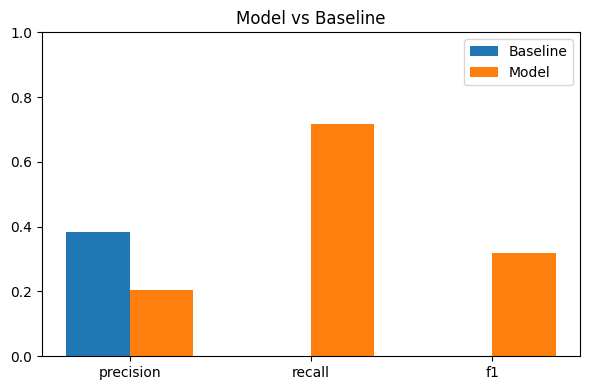

In [61]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['precision', 'recall', 'f1']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(x - width/2, results.loc[0, metrics], width, label='Baseline')
ax.bar(x + width/2, results.loc[1, metrics], width, label='Model')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_title('Model vs Baseline')
ax.legend()
plt.tight_layout()
plt.savefig('model_vs_baseline.png', dpi=150)
plt.show()

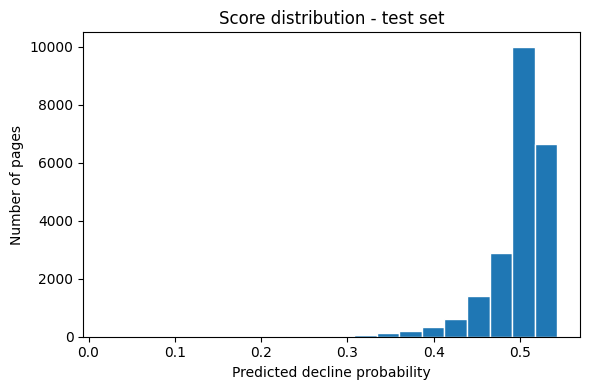

In [62]:
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(action_table['decline_probability'], bins=20, edgecolor='white')
ax.set_xlabel('Predicted decline probability')
ax.set_ylabel('Number of pages')
ax.set_title('Score distribution - test set')
plt.tight_layout()
plt.savefig('score_distribution.png', dpi=150)
plt.show()

ML-12 CLOSING CELLs
5-minute demo outline:
1. State the question, prioritizing pages for refresh review
2. Show the baseline rule and why it's a simple starting point
3. Show the model, features used, and why they're leakage safe
4. Walk through the results table and the model vs baseline chart
5. Close on the ranked recommendations table and limitations

Social post cut:
Built a logistic regression model to flag which pages are likely to lose
search visibility next month, tested honestly against a simple rule based
baseline on real search performance data.

3-sentence employer facing summary:
This project scores a page inventory to prioritize content refresh decisions,
comparing a simple rule-based baseline against a logistic regression model
trained on leakage-checked, closed-month features. The model was validated
on a held-out split and evaluated against the baseline on precision, recall,
f1, and roc auc, catching far more true decline cases than the baseline.
Results are shown as decision-support rankings, not causal claims, and the
project credits the FlyRank ML Internship dataset as its data source.

## Acknowledgments & Data Credit

This project utilizes the FlyRank ML Internship dataset, available at `https://flyrank.ai`.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


## Acknowledgments & Data Credit

This project utilizes the FlyRank ML Internship dataset, available at `https://flyrank.ai`.